# Exploratory Data Analysis (EDA)
## Step 1: NAV Trend Analysis (2022–2026)

In [145]:
import pandas as pd
import plotly.express as px

In [146]:
nav = pd.read_csv("data/processed/02_nav_history.csv")

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [147]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


In [148]:
nav["date"] = pd.to_datetime(nav["date"])

In [149]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[ns]
 2   nav        46000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 1.1 MB


In [150]:
# Create line chart for NAV trends

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of 40 Mutual Fund Schemes (2022-2026)"
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    line_width=0
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.12,
    line_width=0
)

# Improve chart appearance
fig.update_layout(
    template="plotly_white",
    height=700,
    width=1200
)

# Show chart
fig.show()

### Observation

- The chart shows the daily NAV movement of all 40 mutual fund schemes from 2022 to 2026.
- The green shaded area represents the 2023 bull market period.
- The red shaded area represents the 2024 market correction.
- Different schemes show different growth patterns over time.

## Task 2: AUM Growth Analysis

In [151]:
aum = pd.read_csv("data/raw/03_aum_by_fund_house.csv")

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [152]:
aum.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     object 
 1   fund_house      90 non-null     object 
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 3.6+ KB


In [153]:
aum["date"] = pd.to_datetime(aum["date"])

In [154]:
aum["year"] = aum["date"].dt.year

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


In [155]:
import matplotlib.pyplot as plt
import seaborn as sns

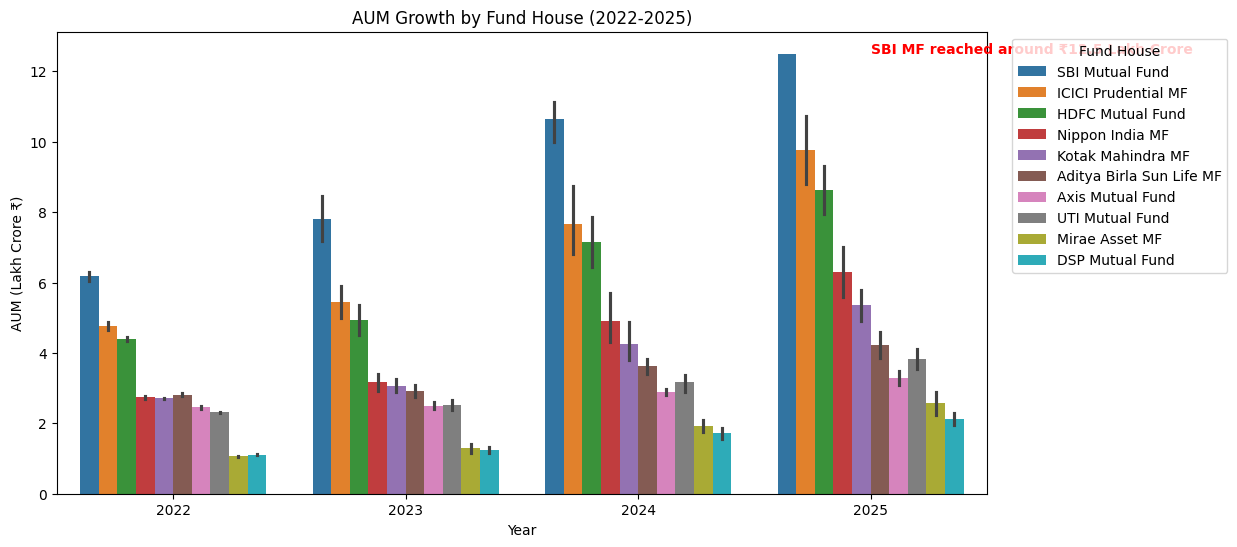

In [156]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore ₹)")
plt.xticks(rotation=0)
plt.legend(title="Fund House", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.text(
    3, 12.5,
    "SBI MF reached around ₹12.5 Lakh Crore",
    fontsize=10,
    color="red",
    fontweight="bold"
)

plt.show()

### Observation

- SBI Mutual Fund recorded the highest AUM among all fund houses.
- The AUM of most fund houses increased steadily from 2022 to 2025.
- SBI Mutual Fund reached around ₹12.5 lakh crore, showing its market leadership.

## Task 3: SIP Inflow Time-Series

In [157]:
sip = pd.read_csv("data/raw/04_monthly_sip_inflows.csv")

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [158]:
sip.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     object 
 1   sip_inflow_crore           48 non-null     int64  
 2   active_sip_accounts_crore  48 non-null     float64
 3   new_sip_accounts_lakh      48 non-null     float64
 4   sip_aum_lakh_crore         48 non-null     float64
 5   yoy_growth_pct             36 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 2.4+ KB


In [159]:
sip["month"] = pd.to_datetime(sip["month"])

In [160]:
sip.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   month                      48 non-null     datetime64[ns]
 1   sip_inflow_crore           48 non-null     int64         
 2   active_sip_accounts_crore  48 non-null     float64       
 3   new_sip_accounts_lakh      48 non-null     float64       
 4   sip_aum_lakh_crore         48 non-null     float64       
 5   yoy_growth_pct             36 non-null     float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 2.4 KB


In [161]:
# Create line chart

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (2022-2025)"
)

# Find the highest SIP inflow
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

# Add annotation
fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text="Highest SIP Inflow (₹31,002 Cr)",
    showarrow=True,
    arrowhead=2
)

fig.show()

In [162]:
sip.loc[sip["sip_inflow_crore"].idxmax()]

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

### Observation

- Monthly SIP inflows increased steadily between 2022 and 2025.
- The highest SIP inflow was recorded in December 2025 at ₹31,002 crore.
- This trend indicates increasing investor participation through SIP investments.

## Task 4: Category inflow heatmap

In [163]:
category = pd.read_csv("data/raw/05_category_inflows.csv")

category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [164]:
category.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    object 
 1   category          144 non-null    object 
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), object(2)
memory usage: 3.5+ KB


In [165]:
category["month"] = pd.to_datetime(category["month"])

In [166]:
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0
Large Cap,2413.0,2076.0,2519.0,2574.0,1940.0,1879.0,2255.0,1870.0,1923.0,2025.0,1925.0,2234.0
Liquid,37537.0,41872.0,40486.0,34643.0,41952.0,35308.0,39091.0,40506.0,34933.0,33892.0,32374.0,38681.0
Mid Cap,3897.0,5300.0,5047.0,4548.0,3899.0,4960.0,4106.0,4336.0,5023.0,4316.0,4819.0,5061.0
Sectoral/Thematic,8052.0,8354.0,10030.0,9896.0,8360.0,8518.0,7680.0,7397.0,9820.0,7893.0,9215.0,8614.0


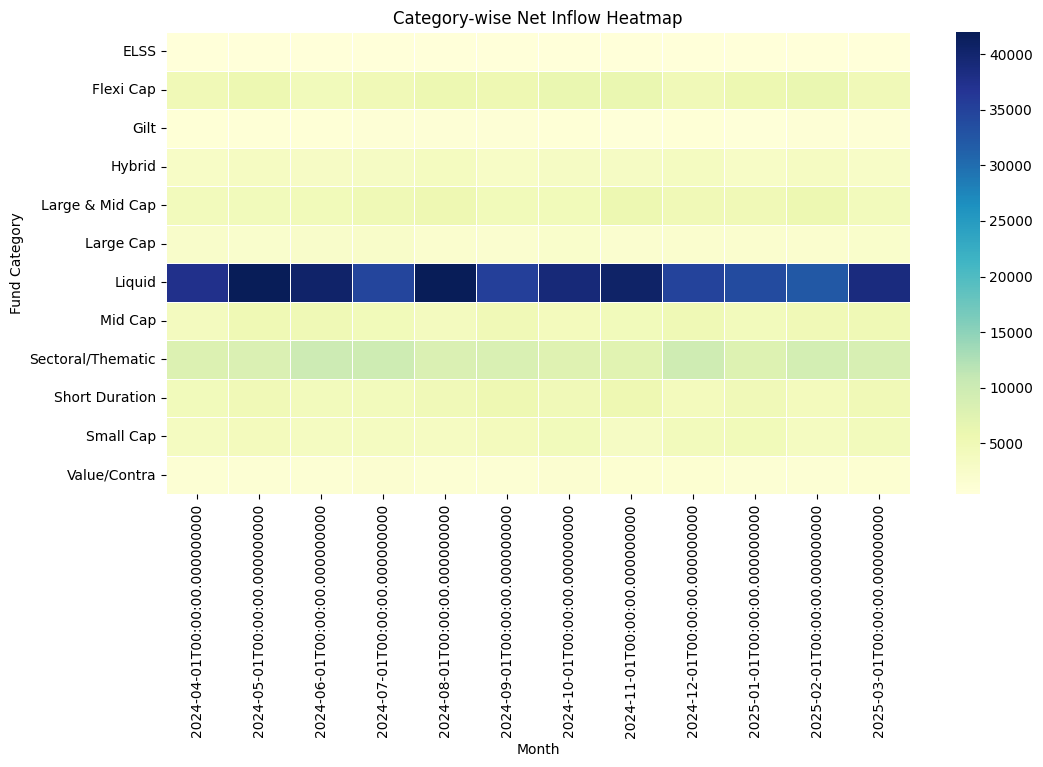

In [167]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=False,
    linewidths=0.5
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.show()

### Observation

- Net inflows vary across different mutual fund categories.
- Some categories consistently attract higher inflows than others.
- The heatmap makes it easy to identify periods of strong and weak investor interest.

## Task 5: Investor Demographics

In [168]:
transactions = pd.read_csv("data/raw/08_investor_transactions.csv")

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [169]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  object 
 1   transaction_date    32778 non-null  object 
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  object 
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  object 
 6   city                32778 non-null  object 
 7   city_tier           32778 non-null  object 
 8   age_group           32778 non-null  object 
 9   gender              32778 non-null  object 
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  object 
 12  kyc_status          32778 non-null  object 
dtypes: float64(1), int64(2), object(10)
memory usage: 3.3+ MB


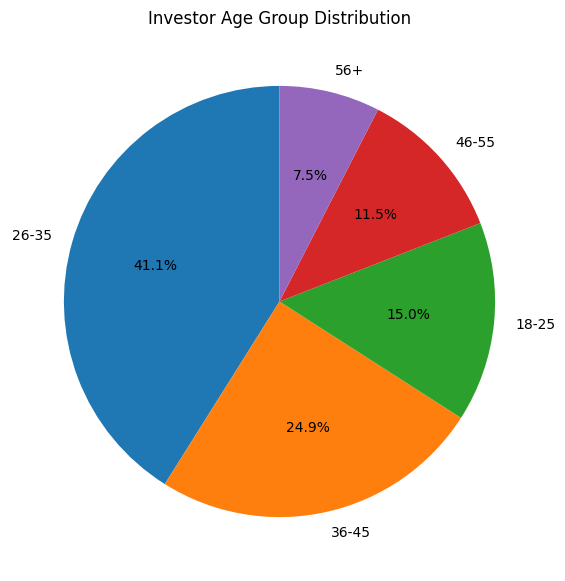

In [170]:
# Count investors in each age group
age_data = transactions["age_group"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    age_data,
    labels=age_data.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.show()

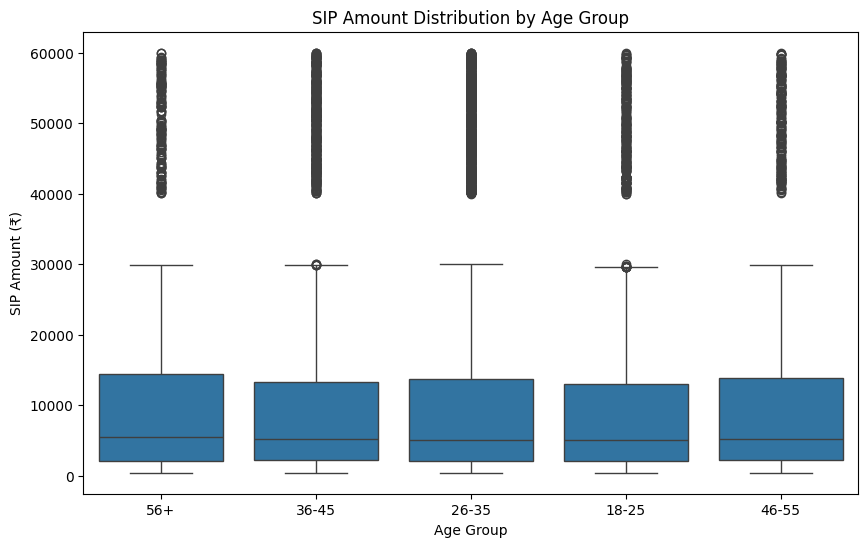

In [171]:
# Select only SIP transactions
sip_data = transactions[transactions["transaction_type"] == "SIP"]

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=sip_data,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.show()

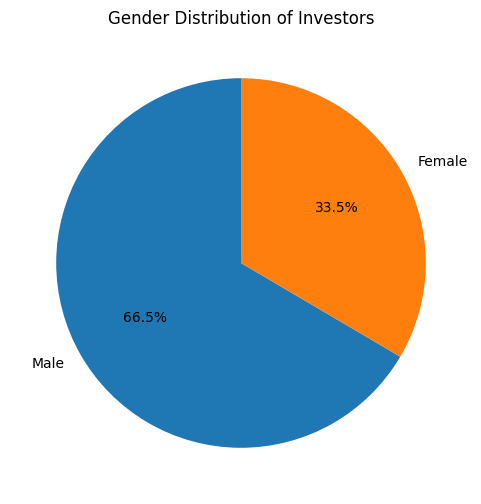

In [172]:
gender_data = transactions["gender"].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    gender_data,
    labels=gender_data.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution of Investors")

plt.show()

### Observation

- The investor base is distributed across different age groups.
- SIP investment amounts vary among different age groups.
- The gender distribution provides an overview of male and female investor participation.

## Task 6: Geographic Distribution

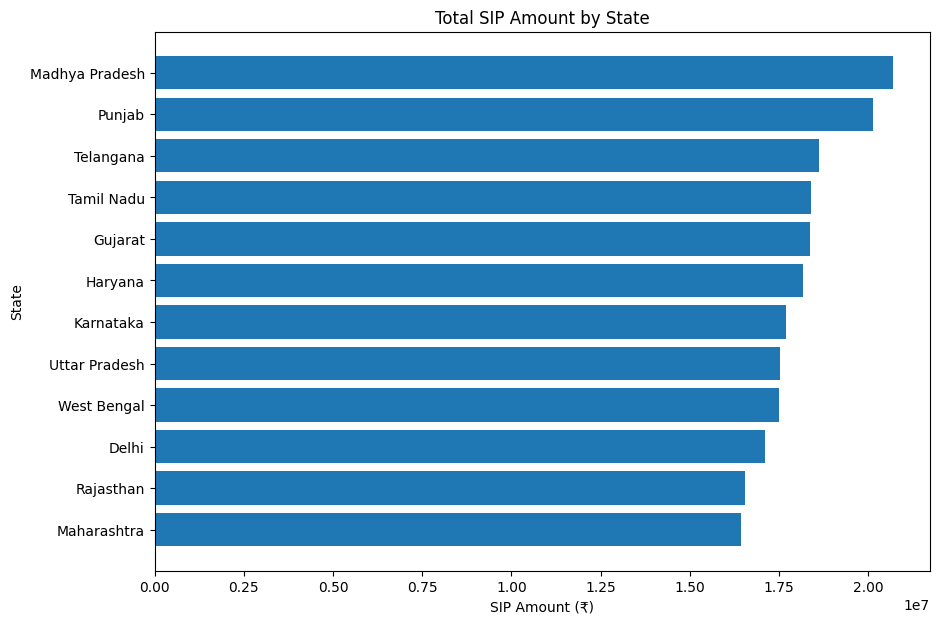

In [173]:
# Select only SIP transactions
sip_data = transactions[transactions["transaction_type"] == "SIP"]

# Total SIP amount by state
state_data = sip_data.groupby("state")["amount_inr"].sum().sort_values()

plt.figure(figsize=(10, 7))

plt.barh(
    state_data.index,
    state_data.values
)

plt.title("Total SIP Amount by State")
plt.xlabel("SIP Amount (₹)")
plt.ylabel("State")

plt.show()

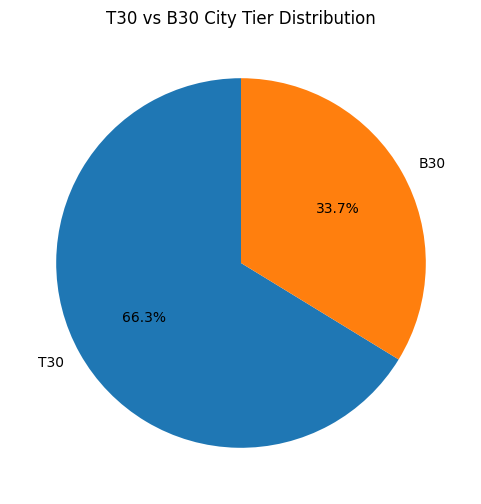

In [174]:
city_data = transactions["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    city_data,
    labels=city_data.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 City Tier Distribution")

plt.show()

### Observation

- SIP investments are distributed across multiple states.
- Some states contribute more SIP investments than others.
- The city tier chart shows the distribution of investors between T30 and B30 cities.

## Task 7: Folio Count Growth

In [175]:
folio = pd.read_csv("data/raw/06_industry_folio_count.csv")

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [176]:
folio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                21 non-null     object 
 1   total_folios_crore   21 non-null     float64
 2   equity_folios_crore  21 non-null     float64
 3   debt_folios_crore    21 non-null     float64
 4   hybrid_folios_crore  21 non-null     float64
 5   others_folios_crore  21 non-null     float64
dtypes: float64(5), object(1)
memory usage: 1.1+ KB


In [177]:
folio["month"] = pd.to_datetime(folio["month"])

In [178]:
folio.loc[folio["total_folios_crore"].idxmax()]

month                  2025-12-01 00:00:00
total_folios_crore                   26.12
equity_folios_crore                  18.28
debt_folios_crore                     3.66
hybrid_folios_crore                   1.57
others_folios_crore                   2.61
Name: 20, dtype: object

In [179]:
# Create line chart

fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    title="Growth of Mutual Fund Folios (2022-2025)"
)

# Find the highest folio count
max_row = folio.loc[folio["total_folios_crore"].idxmax()]

# Add annotation
fig.add_annotation(
    x=max_row["month"],
    y=max_row["total_folios_crore"],
    text="Highest Folio Count (26.12 Cr)",
    showarrow=True,
    arrowhead=2
)

# Show chart
fig.show()

### Observation

- Mutual fund folios increased steadily from 2022 to 2025.
- The highest folio count reached 26.12 crore in December 2025.
- The continuous increase indicates growing investor participation in mutual funds.

## Task 8: NAV Return Correlation Matrix

In [180]:
# Select first 10 mutual fund schemes
selected_funds = nav["amfi_code"].unique()[:10]

selected_funds

array([100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886,
       102887, 118632])

In [181]:
nav_10 = nav[nav["amfi_code"].isin(selected_funds)]

nav_10.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [182]:
nav_pivot = nav_10.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

nav_pivot.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585


In [183]:
returns = nav_pivot.pct_change()

returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793


In [184]:
correlation = returns.corr()

correlation

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384
101208,-0.033773,0.018455,0.007864,-0.027230,-0.007530,1.000000,-0.001436,0.014307,0.036547,0.003507
102885,-0.093533,-0.001038,-0.034228,0.001570,-0.005929,-0.001436,1.000000,0.020691,-0.036704,-0.000285
102886,-0.005867,0.013754,-0.018166,0.007229,0.004860,0.014307,0.020691,1.000000,-0.007865,-0.039886
102887,-0.023316,-0.005648,-0.036647,-0.006490,0.002304,0.036547,-0.036704,-0.007865,1.000000,0.001248


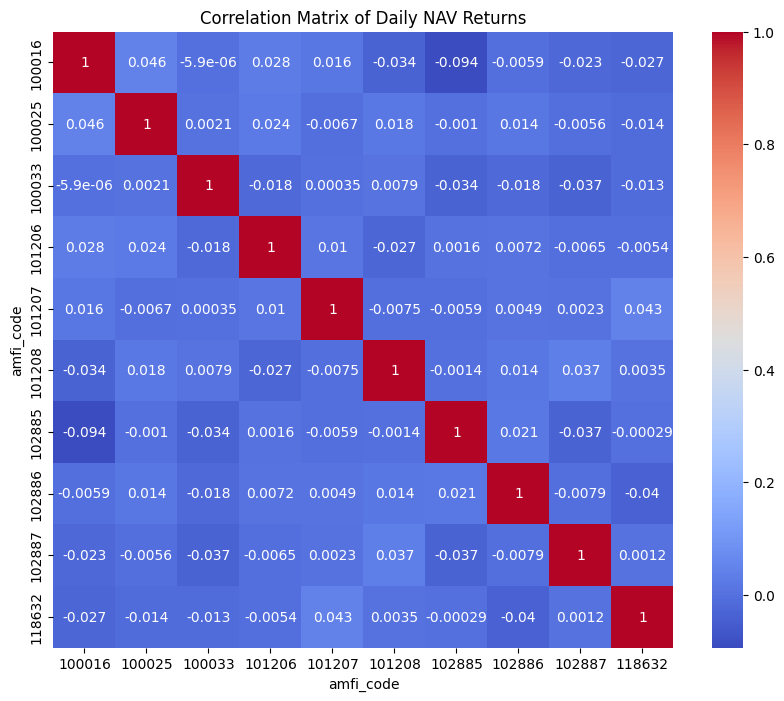

In [185]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    annot=True
)

plt.title("Correlation Matrix of Daily NAV Returns")

plt.show()

### Observation

- Most mutual fund schemes show a positive correlation in daily returns.
- Some fund pairs have stronger correlations than others.
- The heatmap helps identify funds with similar return patterns.

## Task 9: Sector Allocation Donut Chart

In [186]:
holdings = pd.read_csv("data/raw/09_portfolio_holdings.csv")

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [187]:
holdings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    object 
 2   stock_name         322 non-null    object 
 3   sector             322 non-null    object 
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    object 
dtypes: float64(3), int64(1), object(4)
memory usage: 20.3+ KB


In [188]:
# Total weight by sector
sector_data = holdings.groupby("sector")["weight_pct"].sum()

sector_data

sector
Automobile        323.65
Banking           652.26
Cement            105.03
Consumer Goods    127.61
Diversified       169.23
Energy            117.91
FMCG              229.11
IT                455.47
Infrastructure    192.16
NBFC              119.09
Paints             89.86
Pharma            407.45
Telecom           145.62
Utilities         265.54
Name: weight_pct, dtype: float64

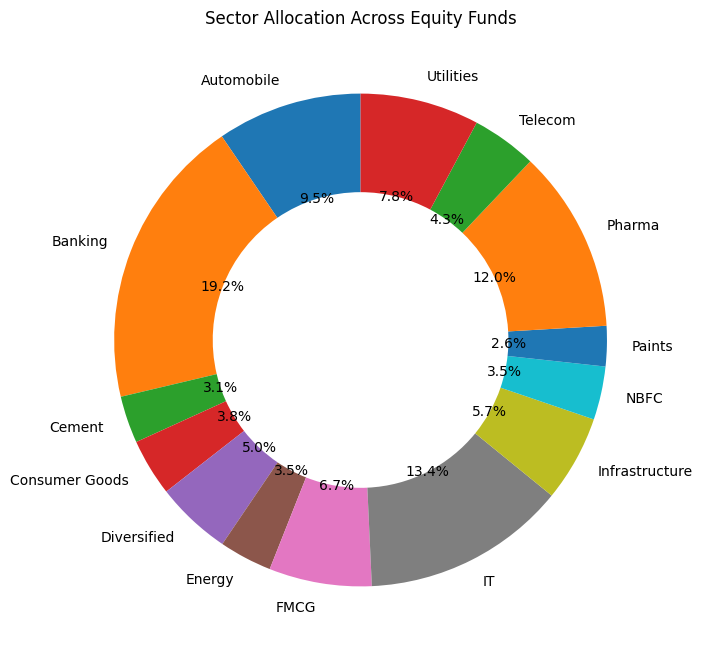

In [189]:
plt.figure(figsize=(8, 8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4}
)

plt.title("Sector Allocation Across Equity Funds")

plt.show()

### Observation

- Portfolio allocation is spread across multiple sectors.
- Banking, Utilities and Pharma are among the major sectors in the portfolio.
- The donut chart provides a clear view of sector-wise allocation across equity funds.

# Task 10: Key EDA Findings

1. The NAV of mutual fund schemes showed an overall upward trend between 2022 and 2026. *(Refer: Task 1 - NAV Trend Analysis)*

2. SBI Mutual Fund maintained the highest Assets Under Management (AUM) among the selected fund houses. *(Refer: Task 2 - AUM Growth Chart)*

3. Monthly SIP inflows increased steadily and reached an all-time high of ₹31,002 crore in December 2025. *(Refer: Task 3 - SIP Inflow Time-Series)*

4. Liquid funds received the highest net inflows compared to most other mutual fund categories. *(Refer: Task 4 - Category Inflow Heatmap)*

5. Investors from different age groups actively participated in mutual fund investments, with varying SIP investment amounts. *(Refer: Task 5 - Investor Demographics)*

6. Mutual fund investments were spread across multiple Indian states, showing broad geographical participation. *(Refer: Task 6 - Geographic Distribution)*

7. T30 and B30 cities both contributed significantly to mutual fund investments. *(Refer: Task 6 - City Tier Distribution)*

8. Total mutual fund folios increased from 13.26 crore in 2022 to 26.12 crore in 2025, indicating strong investor growth. *(Refer: Task 7 - Folio Count Growth)*

9. Most selected mutual fund schemes showed a positive correlation in daily NAV returns. *(Refer: Task 8 - Correlation Matrix)*

10. Banking, IT and Pharma were among the major sectors represented in the equity portfolio allocation. *(Refer: Task 9 - Sector Allocation Donut Chart)*